In [ ]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
import statsmodels.api as sm
import statsmodels.formula.api as smf

# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum

# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''



In [2]:
path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_8416\1624554895.py:2: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(187851, 132)


In [3]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [4]:
# 根据原先的has_face设置，标记host_has_valid_pic
# print(df_all.has_face.value_counts(dropna=False))
# df_all['host_has_valid_pic']=df_all['has_face'].apply(lambda x : 1 if pd.notna(x) else 0)
# print(df_all.host_has_valid_pic.value_counts(dropna=False))

# #无valid pic匹配的：
## has_face,is_smiling 填0, host_picture_type填no_person
df_all['has_face']=df_all['has_face'].fillna(0)
df_all['is_smiling']=df_all['is_smiling'].fillna(0)
# df_all['is_smiling'].value_counts(dropna=False)

df_all['host_picture_type']=df_all['host_picture_type'].fillna("no_person")
# print(df_all.host_picture_type.value_counts(dropna=False))

### age_class +gender填unk!
df_all['age_class']=df_all['age_class'].fillna("unk")
df_all['gender']=df_all['gender'].fillna("unk")
# print(df_all.age_class.value_counts(dropna=False))
# print(df_all.gender.value_counts(dropna=False))

host_pic_vars=[
    # "host_has_profile_pic",
    # 'bbox_list',
    'has_face',
    'host_picture_type',
    # 'smile_score',
    'is_smiling',
    # 'dominant_emotion',
    # 'age',
    'age_class',
    'gender'
]

df_all[host_pic_vars].isna().value_counts()


has_face  host_picture_type  is_smiling  age_class  gender
False     False              False       False      False     187851
Name: count, dtype: int64

In [ ]:
# ## dummies
# if not 'pic_pro_style' in df_all.columns:
#     df_all['pic_pro_style']=df_all['host_picture_type'].apply(lambda x : 1 if x=="pro_style" else 0)
#     print(df_all.pic_pro_style.value_counts(dropna=False))
# if not 'pic_life_style' in df_all.columns:
#     df_all['pic_life_style']=df_all['host_picture_type'].apply(lambda x : 1 if x=="life_style" else 0)
#     print(df_all.pic_life_style.value_counts(dropna=False))
# if not 'pic_no_person' in df_all.columns:
#     df_all['pic_no_person']=df_all['host_picture_type'].apply(lambda x : 1 if x=="no_person" else 0)
#     print(df_all.pic_no_person.value_counts(dropna=False))


In [ ]:
# if not pd.api.types.is_numeric_dtype(df_all['host_is_superhost']):
#     df_all['host_is_superhost']=df_all['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
#     print(df_all.host_is_superhost.value_counts(dropna=False))

In [4]:
tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
# df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all[tactics_bio].isna().value_counts()


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          187851
Name: count, dtype: int64

In [ ]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
# df_all.to_csv(path_df, index=False)

In [6]:
df_all['lang'].value_counts()
# df_all['has_text']=df_all['lang'].apply(lambda x: 1 if x!="no_text" else 0)
# print(df_all.has_text.value_counts(dropna=False))

# #通过构建dummy变量，将no_text从lang中分割出来：
# df_all['lang_fr']=df_all['lang'].apply(lambda x : 1 if x =="fr" else 0)
# df_all['lang_en']=df_all['lang'].apply(lambda x : 1 if x =="en" else 0)
print(df_all['lang'].value_counts(dropna=False)/len(df_all))
print(df_all['lang_fr'].value_counts(dropna=False))
print(df_all['lang_en'].value_counts(dropna=False))
print(df_all['text_length'].describe())

lang
no_text        0.503223
en             0.356123
fr             0.130806
other_langs    0.009848
Name: count, dtype: float64
lang_fr
0    163279
1     24572
Name: count, dtype: int64
lang_en
0    120953
1     66898
Name: count, dtype: int64
count    187851.000000
mean         31.008959
std          58.529596
min           0.000000
25%           0.000000
50%           0.000000
75%          43.000000
max        1040.000000
Name: text_length, dtype: float64


## changements des tactics:

In [ ]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model
import statsmodels.api as sm
import statsmodels.formula.api as smf

    
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", 
    "text_length",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
]  

tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=["host_picture_type","is_smiling"]
group_vars=["in_paris","in_2024"]
            
formula= (" is_smiling ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            # "text_length + C(lang) +"
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * in_2024"
)
model=smf.ols(formula, data=df_all).fit(cov_type="HC1")#robust standard errors

summary=model.summary()
print(summary)

# authenticité, sociabilité(r²小), auto_promotion 在jo期间显著积极
# ouverture, exemplarité 不显著

                            OLS Regression Results                            
Dep. Variable:             is_smiling   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     600.2
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:13:19   Log-Likelihood:            -1.0912e+05
No. Observations:              187851   AIC:                         2.183e+05
Df Residuals:                  187825   BIC:                         2.186e+05
Df Model:                          25                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

### ols: + y=categorial tactic

In [34]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf
df=df_all.copy()
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=['pic_no_person','pic_pro_style','pic_life_style', "is_smiling"]

# tactics_pic=["host_picture_type","is_smiling"]

tactics_vars=tactics_bio+tactics_pic
results=[]

for var in tactics_vars:
    # print(f"{var}".center(100,"-"))
    print(var)
    formula= (f" {var}~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
                "C(host_is_superhost) + years_since_host + professional_host + "
                # "C(lang) + text_length +"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "in_paris * in_2024"
    )
    model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
    
    
    coef = model.params["in_paris:in_2024"]
    se = model.bse["in_paris:in_2024"]
    pval = model.pvalues["in_paris:in_2024"]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })

results_df = pd.DataFrame(results)
# 只有auth, socio, promo显著变化，且是显著提升！
# 更多选取有人物的头像！更多微笑！

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
pic_no_person
pic_pro_style
pic_life_style
is_smiling


In [35]:
display(results_df)

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.005434,0.006064,3.701857e-01,,-0.017320,0.006451
1,authenticité,0.039750,0.006327,3.339560e-10,***,0.027348,0.052152
2,sociabilité,0.026491,0.006528,4.949366e-05,***,0.013696,0.039287
3,auto_promotion,0.018120,0.005970,2.406109e-03,**,0.006418,0.029822
4,exemplarité,0.007319,0.006150,2.340532e-01,,-0.004736,0.019374
5,pic_no_person,-0.033036,0.004015,1.889393e-16,***,-0.040905,-0.025168
6,pic_pro_style,0.010264,0.004425,2.038092e-02,*,0.001590,0.018938
7,pic_life_style,0.022773,0.004282,1.047968e-07,***,0.014380,0.031165
8,is_smiling,0.042240,0.004115,1.023090e-24,***,0.034174,0.050305


<Figure size 640x480 with 0 Axes>

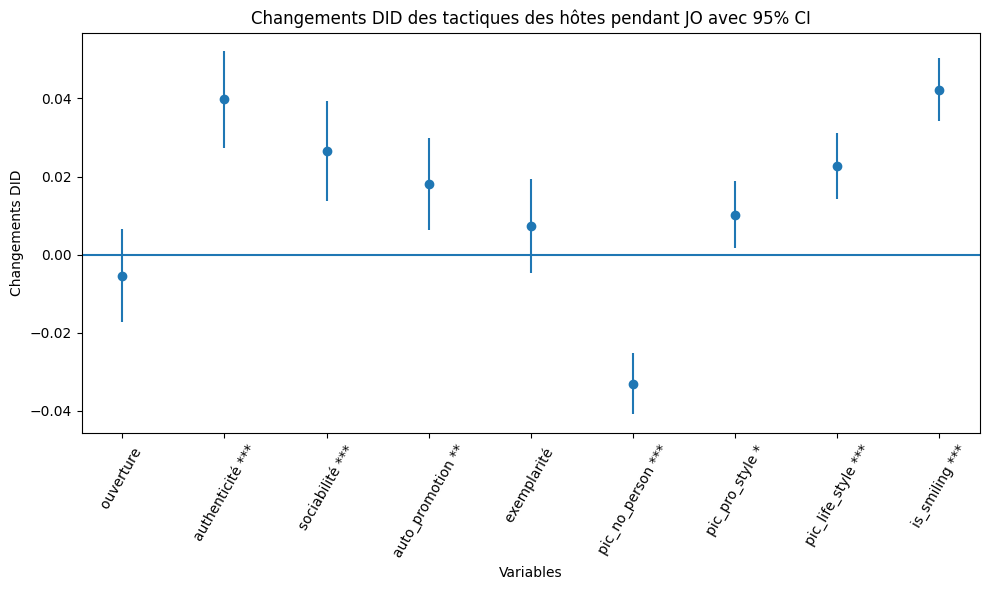

In [38]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## effect des tactiques sur booking_rate + si/comment jo influence son effect?
有number_of_reviews版本，关键变量coef变化不大

In [10]:
x_vars=["host_identity_verified",      
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",#"number_of_reviews_till_Q",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    "host_response_rate","host_response_time",
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    # "lang", 
    "has_text","lang_en","lang_fr","text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type",'pic_no_person','pic_pro_style','pic_life_style',
    "is_smiling","age_class","gender",
    "in_paris",'in_2024'
]  

df=df_all.copy()
df[x_vars].isna().value_counts(dropna=False)

host_identity_verified  review_scores_rating  has_rating  number_of_reviews_ltm  host_is_superhost  years_since_host  professional_host  host_response_rate  host_response_time  has_text  lang_en  lang_fr  text_length  price  availability_90  room_type  instant_bookable  ouverture  authenticité  sociabilité  auto_promotion  exemplarité  host_picture_type  pic_no_person  pic_pro_style  pic_life_style  is_smiling  age_class  gender  in_paris  in_2024
False                   False                 False       False                  False              False             False              False               False               False     False    False    False        False  False            False      False             False      False         False        False           False        False              False          False          False           False       False      False   False     False      187851
Name: count, dtype: int64

In [ ]:
# basci model 但ctrl中加上 number_of_reviews_ltm
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# host_has_valid_pic coef为负？？？
# number_of_reviews_till_Q没有number_of_reviews_ltm好
# host_response_within_a_day 没有分类变量C(host_response_time) 效果好，反而为负

df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        " is_smiling + "
        "C(age_class) + C(gender) +"
        "in_paris * in_2024"
)

model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     3747.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:27:02   Log-Likelihood:                 56911.
No. Observations:              187851   AIC:                        -1.137e+05
Df Residuals:                  187812   BIC:                        -1.133e+05
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [12]:
# interaction model + number_of_reviews_ltm
# tactics_host* in_paris*in_2024
## ps.# tactics_host* in_paris:in_2024，R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf

# "text_length + C(lang) +"
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "years_since_host + professional_host + "
        "host_response_rate + C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024+"
        "C(age_class) + C(gender) "
        
)
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     2225.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:28:25   Log-Likelihood:                 57551.
No. Observations:              187851   AIC:                        -1.150e+05
Df Residuals:                  187785   BIC:                        -1.143e+05
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## effet réel

In [ ]:
## 每一组的真实effect
import numpy as np
import pandas as pd
from itertools import product
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
    
def get_did_marginal_effect(
    model, 
    key_var,
    paris_var="in_paris",
    time_var="in_2024"
):
    """
    每组中，叠加的真实效应
    
    """
    params = model.params
    param_names = params.index.tolist()

    rows = []

    # 四种组合
    for p, t in product([0,1], [0,1]):
        # 用0,1标注出我们要交互的vars的index:
        lin_comb = np.zeros(len(params))
        # 主效应
        if key_var in param_names:
            lin_comb[param_names.index(key_var)] = 1

        # key_var × paris
        term = f"{key_var}:{paris_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p

        # key_var × time
        term = f"{key_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = t

        # triple interaction
        term = f"{key_var}:{paris_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p * t
        # print(lin_comb)
        
        # t-test
        t_res = model.t_test(lin_comb)
        # print(t_res)
        rows.append({
            "in_paris": p,
            "in_2024": t,
            "group": f"{'Paris' if p ==1 else 'London'} {'2024' if t ==1 else '2023'}",
            "coef": float(t_res.effect),
            "se": float(t_res.sd),
            "t": float(t_res.tvalue),
            "pval": float(t_res.pvalue),
            "sig": p_to_sig(float(t_res.pvalue)),            
        })
    result_df= pd.DataFrame(rows)
    result_df['label']=result_df['group']+' '+result_df['sig']
    
    return result_df

res = get_did_marginal_effect(model=model_interaction, key_var="C(host_picture_type)[T.no_person]", paris_var="in_paris", time_var="in_2024")
display(res)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig,label
0,0,0,London 2023,-0.020105,0.002372,-8.476301,2.341149e-17,***,London 2023 ***
1,0,1,London 2024,-0.001662,0.002221,-0.748377,4.542338e-01,,London 2024
2,1,0,Paris 2023,-0.031537,0.002774,-11.370540,5.996292e-30,***,Paris 2023 ***
3,1,1,Paris 2024,0.008158,0.002092,3.900197,9.614797e-05,***,Paris 2024 ***


In [14]:
var='C(host_is_superhost)[T.1]'
model=model_interaction
res = get_did_marginal_effect(model, key_var=var, paris_var="in_paris", time_var="in_2024")
display(res)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig,label
0,0,0,London 2023,0.027488,0.002782,9.882340,5.030706e-23,***,London 2023 ***
1,0,1,London 2024,0.001798,0.001904,0.944249,3.450438e-01,,London 2024
2,1,0,Paris 2023,0.052925,0.002547,20.778270,8.730502e-96,***,Paris 2023 ***
3,1,1,Paris 2024,-0.004671,0.001874,-2.492200,1.269631e-02,*,Paris 2024 *


In [15]:
# did = model.params["authenticité:in_paris:in_2024"]
# pval = model.pvalues["authenticité:in_paris:in_2024"]
# title = f"authenticité (DID = {did:.3f}, p={pval:.3f})"

import numpy as np

def get_linear_pval(model, terms):
    """
    did's pval(β4: in_paris:in_2024)
    
    """
    # 取出所有变量，初始化为0
    params = model.params.index.tolist()
    L = np.zeros(len(params))
    
    # 输入变量的位置标记为1 (terms={in_paris:1, ...}) 
    for name, weight in terms.items():
        if name in params:
            L[params.index(name)] = weight
    res = model.t_test(L)
    return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


def get_did_summary(model, var, paris_var="in_paris", time_var="in_2024"):
    params = model.params
    cov = model.cov_params()

    def get_coef(name):
        return params[name] if name in params else 0

    def get_var(name):
        return cov.loc[name, name] if name in cov.index else 0
    
    def get_pval(name):
        return params[name, name] if name in params else 0

    # 系数名
    b1 = var
    b2 = f"{var}:{paris_var}"
    b3 = f"{var}:{time_var}"
    b4 = f"{var}:{paris_var}:{time_var}"

    # DID = β4
    # did_coef = get_coef(b4)
    # did_se = (get_var(b4)) ** 0.5
    # did_p=get_pval(b4)
    did_coef, did_se, did_pval, did_sig = get_linear_pval(model, {
        f"{b4}": 1
    })
    
    # London change = β3
    london_coef = get_coef(b3)
    london_se = (get_var(b3)) ** 0.5
    # london_p=get_pval(b3)
    london_coef, london_se, london_pval, london_sig = get_linear_pval(model, {
        f"{b3}": 1
    })
    
    # Paris change = β3 + β4
    # paris_coef = get_coef(b3) + get_coef(b4)      
    # # 简化（忽略cov）
    # paris_se = (get_var(b3) + get_var(b4)) ** 0.5
    
    paris_coef, paris_se, paris_pval, paris_sig = get_linear_pval(model, {
        f"{b3}": 1,
        f"{b4}": 1
    })
    
    
    return pd.DataFrame({
        "type": ["London change", "Paris change", "DID"],
        "coef": [london_coef, paris_coef, did_coef],
        "se": [london_se, paris_se, did_se],
        'pval':[london_pval, paris_pval, did_pval],
        "sig":[london_sig, paris_sig, did_sig],
        # 'label':
        'tactic':var
    })

var="C(host_is_superhost)[T.1]"

result_did= get_did_summary(model=model_interaction, var=var)
display(result_did)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\5715242.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


,type,coef,se,pval,sig,tactic
0,London change,-0.025690,0.003334,1.304289e-14,***,C(host_is_superhost)[T.1]
1,Paris change,-0.057596,0.003100,5.742421e-77,***,C(host_is_superhost)[T.1]
2,DID,-0.031906,0.004542,2.145571e-12,***,C(host_is_superhost)[T.1]


## plot data

In [16]:
# test var categorielle
res = get_did_marginal_effect(model=model_interaction, key_var="C(host_picture_type)[T.pro_style]", paris_var="in_paris", time_var="in_2024")
display(res)

res = get_did_marginal_effect(model=model_interaction, key_var="C(host_picture_type)[T.no_person]", paris_var="in_paris", time_var="in_2024")
display(res)



C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig,label
0,0,0,London 2023,0.000446,0.002149,0.207613,0.835532,,London 2023
1,0,1,London 2024,0.004305,0.002026,2.124464,0.033633,*,London 2024 *
2,1,0,Paris 2023,0.003727,0.002415,1.543163,0.122793,,Paris 2023
3,1,1,Paris 2024,0.002776,0.001744,1.591949,0.111398,,Paris 2024


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig,label
0,0,0,London 2023,-0.020105,0.002372,-8.476301,2.341149e-17,***,London 2023 ***
1,0,1,London 2024,-0.001662,0.002221,-0.748377,4.542338e-01,,London 2024
2,1,0,Paris 2023,-0.031537,0.002774,-11.370540,5.996292e-30,***,Paris 2023 ***
3,1,1,Paris 2024,0.008158,0.002092,3.900197,9.614797e-05,***,Paris 2024 ***


In [22]:

# effet réel 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

tactics_bio = [
    "ouverture", "authenticité","sociabilité",
    "auto_promotion","exemplarité"
]
tactics_pic=["C(host_picture_type)[T.pro_style]","C(host_picture_type)[T.no_person]","is_smiling"]
# 'C(host_is_superhost)[T.1]'
# "C(host_picture_type)[T.no_person]"


tactics= tactics_bio+tactics_pic

# print(f"{len(tactics)} tactics:{tactics}\n")

model=model_interaction


# ---------- 收集所有结果 ----------
all_results = []
for var in tactics:
    print(var)
    res = get_did_marginal_effect(model=model, key_var=var, paris_var="in_paris", time_var="in_2024")
    res["tactic"] = var
    all_results.append(res)
    # break
all_results_df=pd.concat(all_results, ignore_index=True)
all_results_df=all_results_df.sort_values(['tactic','in_paris','in_2024'])

#整理顺序
all_results_df = (
    all_results_df
    .assign(tactic=pd.Categorical(all_results_df["tactic"], categories=tactics, ordered=True))
    .sort_values("tactic")
    .reset_index(drop=True)
)
display(all_results_df)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.pro_style]
C(host_picture_type)[T.no_person]
is_smiling


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3731581580.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036

,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
0,1,1,Paris 2024,-0.001788,0.001415,-1.263506,2.064090e-01,,Paris 2024,ouverture
1,1,0,Paris 2023,-0.005055,0.001781,-2.838961,4.526549e-03,**,Paris 2023 **,ouverture
2,0,1,London 2024,0.002796,0.001453,1.924268,5.432246e-02,.,London 2024 .,ouverture
3,0,0,London 2023,0.000305,0.001512,0.201893,8.400004e-01,,London 2023,ouverture
4,0,0,London 2023,0.006741,0.001524,4.424285,9.681657e-06,***,London 2023 ***,authenticité
5,0,1,London 2024,0.002738,0.001445,1.894159,5.820543e-02,.,London 2024 .,authenticité
6,1,0,Paris 2023,0.011056,0.001768,6.253996,4.009387e-10,***,Paris 2023 ***,authenticité
7,1,1,Paris 2024,-0.001580,0.001446,-1.092763,2.744994e-01,,Paris 2024,authenticité
8,1,1,Paris 2024,0.000918,0.001386,0.662505,5.076481e-01,,Paris 2024,sociabilité
9,0,1,London 2024,0.004439,0.001361,3.262520,1.104462e-03,**,London 2024 **,sociabilité


In [23]:
# display(all_results_df[all_results_df["group"]=="Paris 2024"])
# display(all_results_df[all_results_df["group"]=="Paris 2023"])


In [24]:
# beta4 pval
model=model_interaction
results_did=[]
for var in tactics:
    print(var)
    result_did=get_did_summary(model, var)
    results_did.append(result_did)
    
results_did_df=pd.concat(results_did, axis=0)
display(results_did_df)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.pro_style]
C(host_picture_type)[T.no_person]
is_smiling


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\5715242.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


,type,coef,se,pval,sig,tactic
0,London change,0.002490,0.002095,2.344380e-01,,ouverture
1,Paris change,0.003267,0.002212,1.397003e-01,,ouverture
2,DID,0.000777,0.003046,7.986901e-01,,ouverture
0,London change,-0.004003,0.002086,5.499553e-02,.,authenticité
1,Paris change,-0.012637,0.002248,1.886457e-08,***,authenticité
2,DID,-0.008634,0.003066,4.864177e-03,**,authenticité
0,London change,-0.004741,0.001949,1.501255e-02,*,sociabilité
1,Paris change,-0.013207,0.002240,3.754489e-09,***,sociabilité
2,DID,-0.008466,0.002969,4.356021e-03,**,sociabilité
0,London change,0.005504,0.002025,6.565286e-03,**,auto_promotion


## VIS1:点线图

In [72]:
# ## plot one
# res = get_did_marginal_effect(model, key_var="auto_promotion", paris_var="in_paris", time_var="in_2024")
# df_plot = res.copy()
# df_plot = df_plot.sort_values(["in_paris", "in_2024"])

# display(df_plot)
# import matplotlib.pyplot as plt

# plt.figure()

# x = range(len(df_plot))

# plt.errorbar(
#     x,
#     df_plot["coef"],
#     yerr=1.96 * df_plot["se"],
#     fmt='o'
# )

# plt.xticks(
#     x,
#     ["London 2023", "London 2024", "Paris 2023", "Paris 2024"],
#     rotation=20
# )

# plt.axhline(0)

# plt.ylabel("Marginal Effect on Booking Rate")
# plt.title("Effect of [TACTIC] across Groups")

# plt.show()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6680\1881623394.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


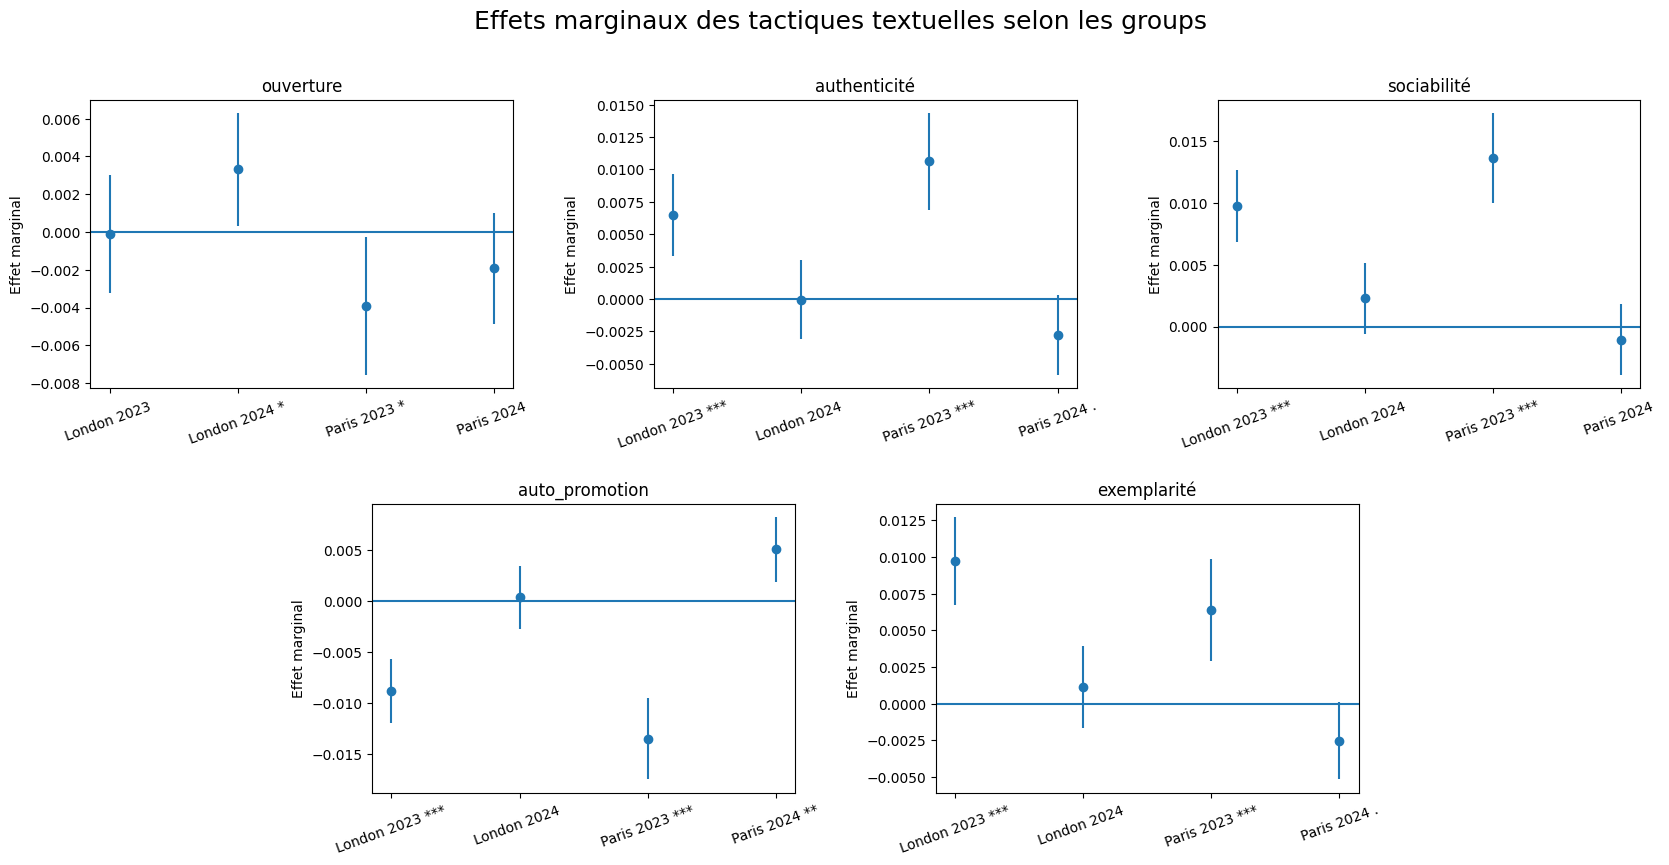

In [ ]:
## VIS 1
# plot_df=all_results_df.copy()

# # --------------------layout-------------------
# # 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
# fig = plt.figure(figsize=(20,9))
# gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

# axes = []

# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
# ax1 = fig.add_subplot(gs[0, 0:2])
# ax2 = fig.add_subplot(gs[0, 2:4])
# ax3 = fig.add_subplot(gs[0, 4:6])
# axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# # 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics_vars), len(axes))
    
# group_labels = ["London 2023", "London 2024", "Paris 2023", "Paris 2024"]

# for i, tactic in enumerate(tactics_bio):
#     ax = axes[i]
#     sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","in_2024"])

#     x = range(4)

#     ax.errorbar(
#         x,
#         sub["coef"],
#         yerr=1.96 * sub["se"],
#         fmt='o'
#     )

#     ax.set_xticks(x)   
#     ax.set_xticklabels(sub['label'], rotation=20)
#     ax.axhline(0)

#     ax.set_title(tactic)
#     ax.set_ylabel("Effet marginal")
    
#     # break 


# fig.suptitle(
#         'Effets marginaux des tactiques textuelles selon les groups',
#         fontsize=18,
#         y=0.98
#     )

# # ---------- 删除第6个空图 ----------
# # fig.delaxes(axes[5])

# # ---------- 调整布局（让第二行居中） ----------
# plt.tight_layout()
# plt.show()

## vis2:折线图

['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\172138078.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


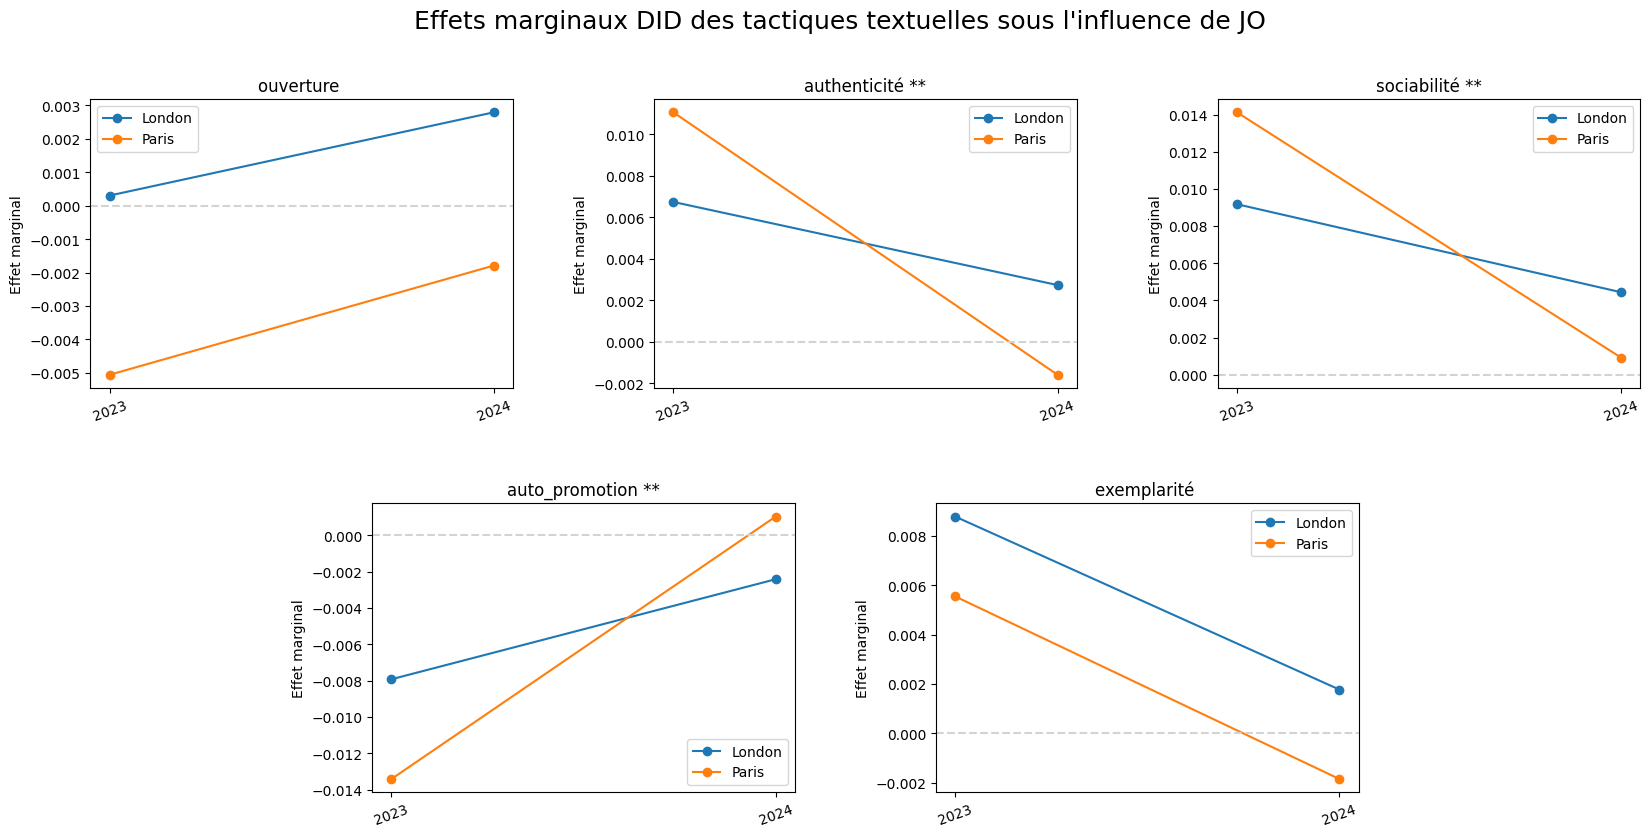

In [25]:

## VIS2: DID 解释因果,策略效果有没有变化
# ps. did可视化，观察不同组效果的差异，而不是一个策略从0-1对于预订率的影响趋势（这种情况采用predict）

plot_df=all_results_df.copy()
tactics_vars=tactics_bio
print(tactics_vars)

# =['ouverture',"authenticité", 'sociabilité', "auto_promotion","exemplarité"]

# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


# ---groups---    
group_labels = ["London 2023", "London 2024", "Paris 2023", "Paris 2024"]

for i, tactic in enumerate(tactics_vars):
    ax = axes[i]
    sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","in_2024"])
    did_sig=results_did_df[(results_did_df['tactic']==tactic)&(results_did_df["type"]=="DID")]['sig'].iloc[0]

    london = sub[sub["in_paris"]==0]
    ax.plot(
        london["in_2024"],
        london["coef"],
        marker='o',
        label="London"
    )
    # Paris
    paris = sub[sub["in_paris"]==1]
    ax.plot(
        paris["in_2024"],
        paris["coef"],
        marker='o',
        label="Paris"
    )
    
    ax.set_xticks([0,1])
    ax.set_xticklabels(["2023", "2024"], rotation=20)
    ax.set_title(f"{tactic} {did_sig}")
    ax.set_ylabel("Effet marginal")
    ax.axhline(y=0, color='lightgray', linestyle='--')

    ax.legend()


fig.suptitle(
        "Effets marginaux DID des tactiques textuelles sous l'influence de JO",
        fontsize=18,
        y=0.98
    )
# ---------- 调整布局（让第二行居中） ----------
plt.legend()
plt.tight_layout()
plt.show()

##标注斜率是否显著？？
## ouverture, exemplarité的效果没有jo很大影响，和london同趋势发展
# auth和socio被压制
# promo上升


In [26]:
plot_df[plot_df['tactic'].isin(tactics_pic)]

,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
20,1,1,Paris 2024,0.002776,0.001744,1.591949,1.113979e-01,,Paris 2024,C(host_picture_type)[T.pro_style]
21,1,0,Paris 2023,0.003727,0.002415,1.543163,1.227929e-01,,Paris 2023,C(host_picture_type)[T.pro_style]
22,0,1,London 2024,0.004305,0.002026,2.124464,3.363269e-02,*,London 2024 *,C(host_picture_type)[T.pro_style]
23,0,0,London 2023,0.000446,0.002149,0.207613,8.355316e-01,,London 2023,C(host_picture_type)[T.pro_style]
24,0,1,London 2024,-0.001662,0.002221,-0.748377,4.542338e-01,,London 2024,C(host_picture_type)[T.no_person]
25,1,0,Paris 2023,-0.031537,0.002774,-11.370540,5.996292e-30,***,Paris 2023 ***,C(host_picture_type)[T.no_person]
26,1,1,Paris 2024,0.008158,0.002092,3.900197,9.614797e-05,***,Paris 2024 ***,C(host_picture_type)[T.no_person]
27,0,0,London 2023,-0.020105,0.002372,-8.476301,2.341149e-17,***,London 2023 ***,C(host_picture_type)[T.no_person]
28,0,1,London 2024,-0.000628,0.002050,-0.306582,7.591620e-01,,London 2024,is_smiling
29,0,0,London 2023,0.001372,0.002176,0.630569,5.283228e-01,,London 2023,is_smiling


['C(host_picture_type)[T.pro_style]', 'C(host_picture_type)[T.no_person]', 'is_smiling']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\1160151795.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


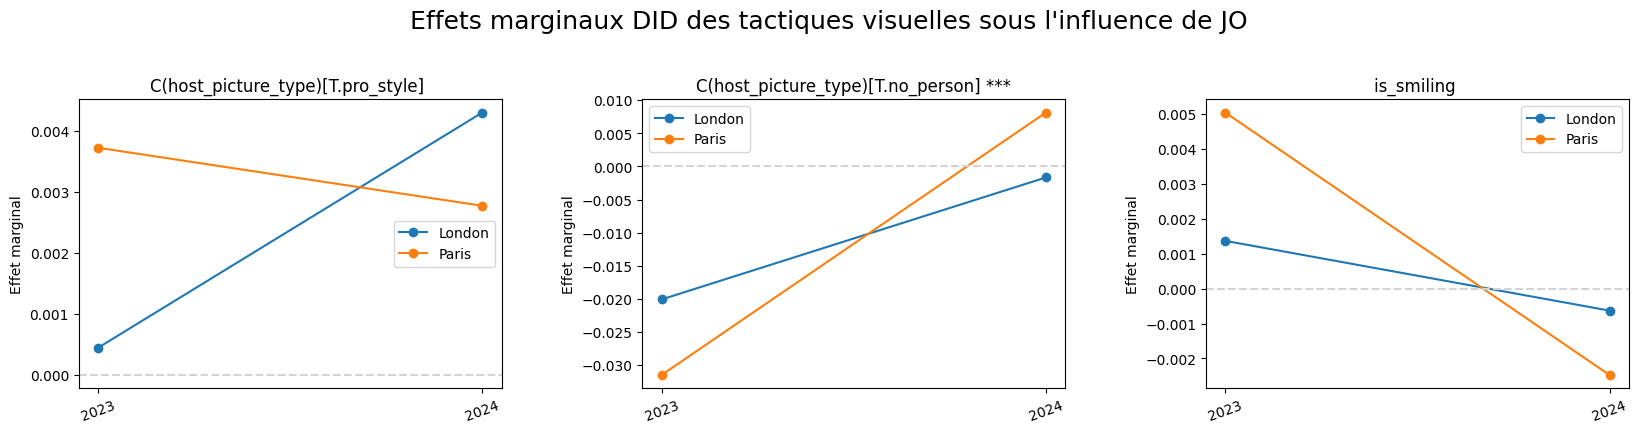

In [28]:

plot_df=all_results_df.copy()
tactics_vars=tactics_pic
print(tactics_vars)
# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


# ---groups---    
group_labels = ["London 2023", "London 2024", "Paris 2023", "Paris 2024"]

for i, tactic in enumerate(tactics_vars):
    ax = axes[i]
    sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","in_2024"])
    did_sig=results_did_df[(results_did_df['tactic']==tactic)&(results_did_df["type"]=="DID")]['sig'].iloc[0]

    london = sub[sub["in_paris"]==0]
    ax.plot(
        london["in_2024"],
        london["coef"],
        marker='o',
        label="London"
    )
    # Paris
    paris = sub[sub["in_paris"]==1]
    ax.plot(
        paris["in_2024"],
        paris["coef"],
        marker='o',
        label="Paris"
    )
    
    ax.set_xticks([0,1])
    ax.set_xticklabels(["2023", "2024"], rotation=20)
    ax.set_title(f"{tactic} {did_sig}")
    ax.set_ylabel("Effet marginal")
    ax.axhline(y=0, color='lightgray', linestyle='--')
    ax.legend()


fig.suptitle(
        "Effets marginaux DID des tactiques visuelles sous l'influence de JO",
        fontsize=18,
        y=0.98
    )
# ---------- 调整布局（让第二行居中） ----------
plt.legend()
plt.tight_layout()
plt.show()

##标注斜率是否显著？？
## ouverture, exemplarité的效果没有jo很大影响，和london同趋势发展
# auth和socio被压制
# promo上升


## VIS3 :PARIS 2024: booking_rate90预测折线图

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\3742385218.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


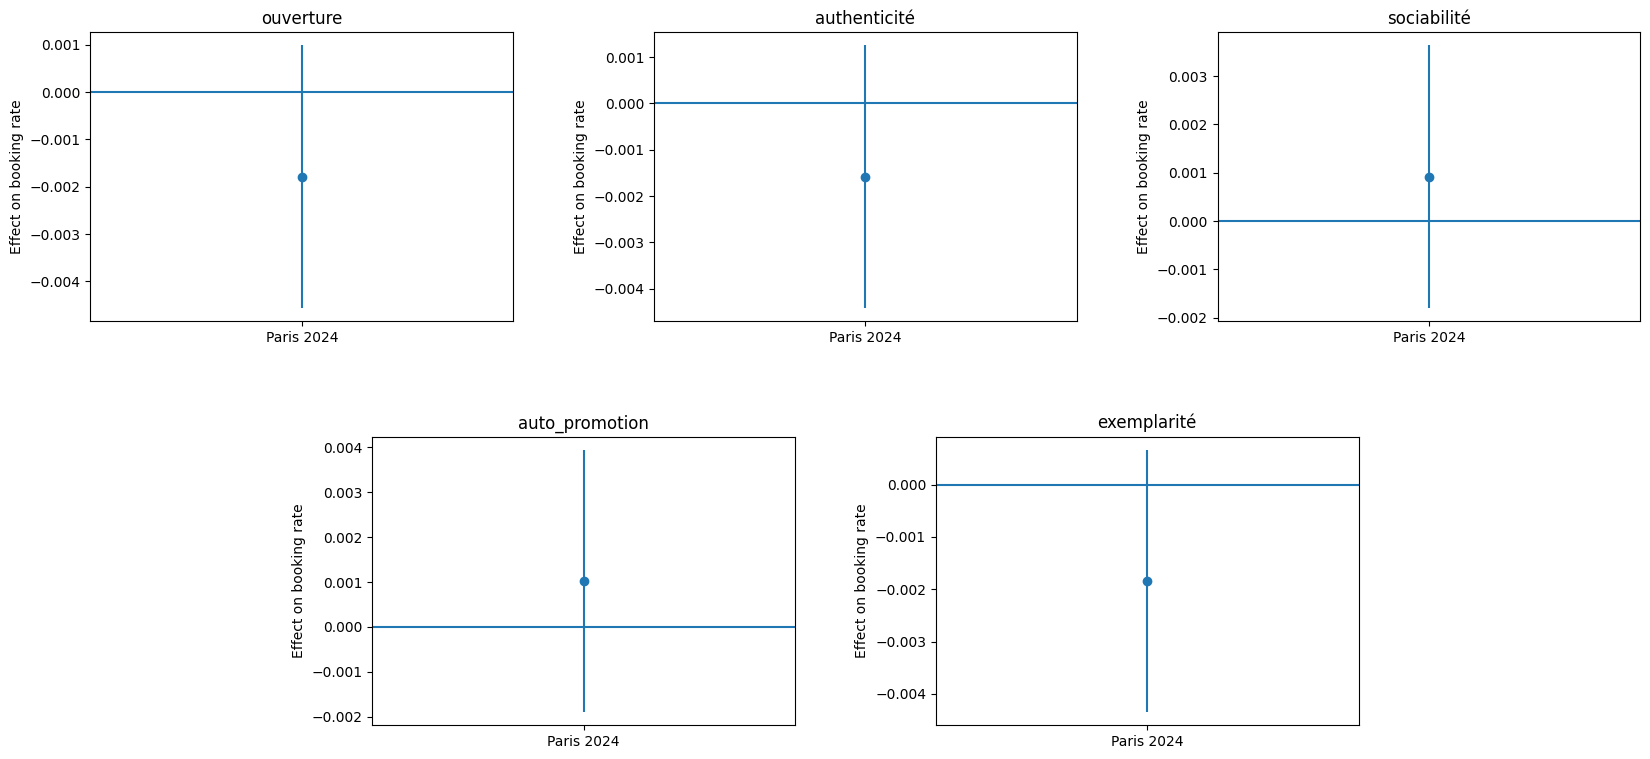

In [29]:
# # 固定时间地点，展示这个策略“实际会带来多少预订变化”
# # Afin d’illustrer l’ampleur économique des effets, nous complétons l’analyse par des courbes de prédiction du taux de réservation.

df_p2024 = all_results_df[
    (all_results_df["in_paris"] == 1) &
    (all_results_df["in_2024"] == 1)
].copy()

import matplotlib.pyplot as plt

tactics_bio = [
    "ouverture", "authenticité","sociabilité",
    "auto_promotion","exemplarité"
]

# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


for i, tactic in enumerate(tactics_bio):
    ax = axes[i]
    
    sub = df_p2024[df_p2024["tactic"] == tactic]

    coef = sub["coef"].values[0]
    se = sub["se"].values[0]
    sig = sub["sig"].values[0]

    # 👉 单个点 + CI
    ax.errorbar(
        [0],
        [coef],
        yerr=[1.96 * se],
        fmt='o'
    )

    # 👉 星号
    if sig != "":
        ax.text(0, coef, sig, ha='center', va='bottom')

    ax.axhline(0)
    
    ax.set_xticks([0])
    ax.set_xticklabels(["Paris 2024"])
    
    ax.set_title(tactic)
    ax.set_ylabel("Effect on booking rate")

plt.tight_layout()
plt.show()


In [30]:
for col in model.model.exog_names:
    if not ':' in col and col != 'Intercept':
        print(col)       

C(host_identity_verified)[T.t]
C(host_response_time)[T.no_response_time]
C(host_response_time)[T.within a day]
C(host_response_time)[T.within a few hours]
C(host_response_time)[T.within an hour]
C(room_type)[T.Hotel room]
C(room_type)[T.Private room]
C(room_type)[T.Shared room]
C(instant_bookable)[T.t]
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]
C(host_is_superhost)[T.1]
review_scores_rating
has_rating
number_of_reviews_ltm
years_since_host
professional_host
host_response_rate
has_text
lang_en
lang_fr
text_length
price
availability_90
ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_smiling
in_paris
in_2024


In [31]:
def plot_predict_curve(model, df, tactic, city="paris", time="2024"):
    # default control values
    default_vals = {}
    for col in model.model.exog_names:
        if ':' in col or col == 'Intercept':
            continue
        var_name = col.split('[')[0].replace('C(', '').replace(')', '')
        if var_name in df.columns:
            if df[var_name].dtype == 'O' or df[var_name].nunique() < 10:
                default_vals[var_name] = df[var_name].mode()[0]
            else:
                default_vals[var_name] = df[var_name].mean()
    tactic_range = np.linspace(df[tactic].min(), df[tactic].max(), 100)

    rows = []
    
    for val in tactic_range:
        row = default_vals.copy()
        row[tactic] = val
        row['in_paris'] = 1 if city=="paris" else 0 #
        row['in_2024'] =  1 if time=="2024" else 0#
        rows.append(row)

    pred_df = pd.DataFrame(rows)

    # type alignment
    for col in pred_df.columns:
        if col in df.columns:
            pred_df[col] = pred_df[col].astype(df[col].dtype)

    preds = model.get_prediction(pred_df)
    sf = preds.summary_frame(alpha=0.05)

    pred_df["y"] = sf["mean"]
    pred_df["low"] = sf["mean_ci_lower"]
    pred_df["high"] = sf["mean_ci_upper"]

    return pred_df

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34036\2466405631.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


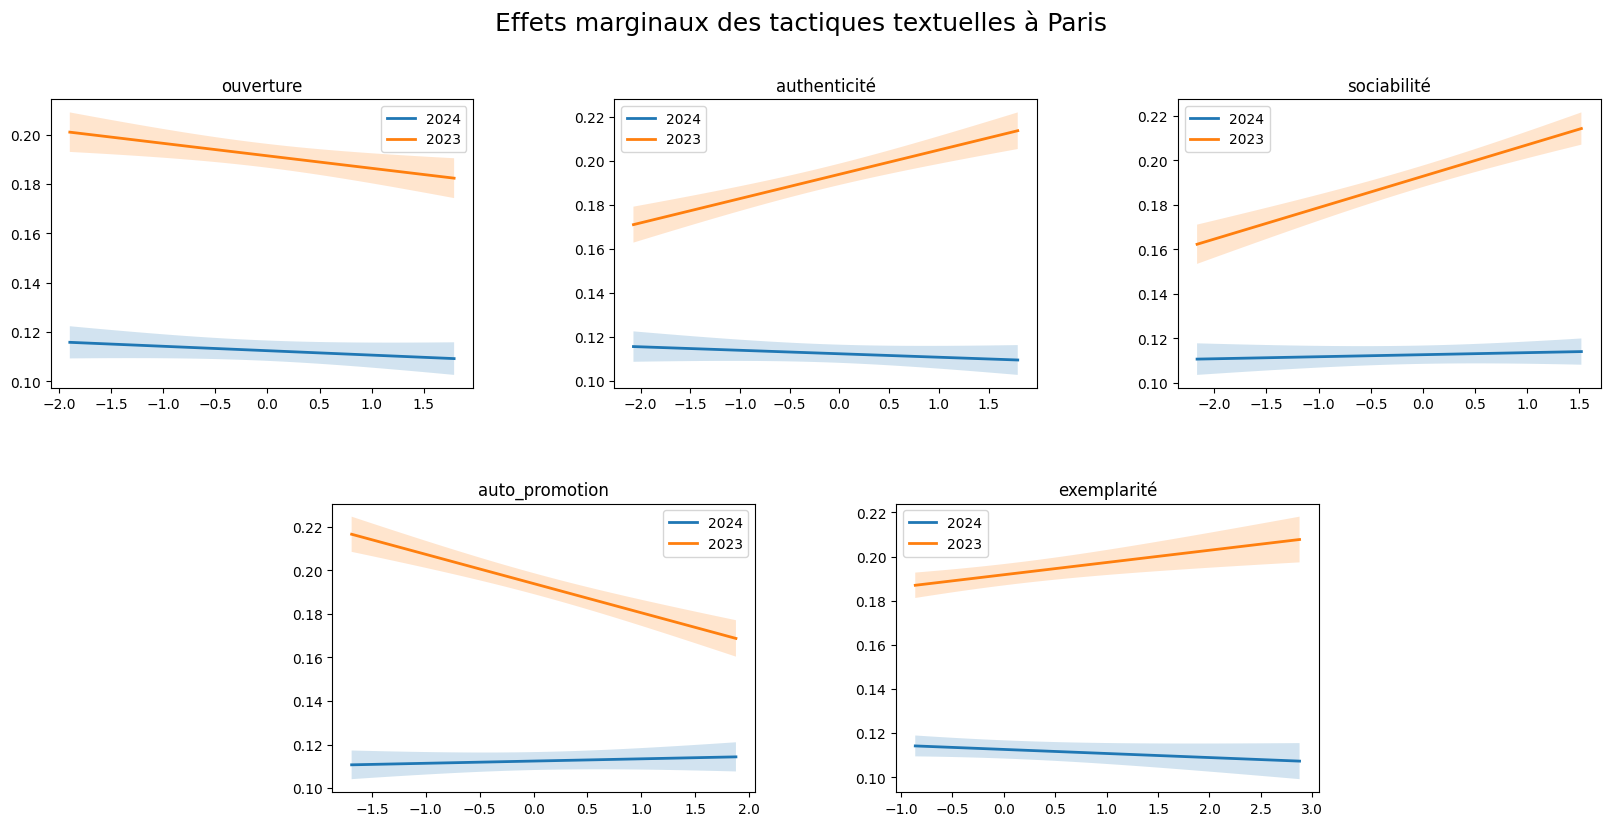

In [33]:
df=df_all.copy()
model=model_interaction
# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


city='paris'
times=['2024',"2023"]
for i, tactic in enumerate(tactics_bio):
    ax = axes[i]
    for time in times:
        pred_df = plot_predict_curve(model, df, tactic, city=city, time=time)
        ax.plot(pred_df[tactic], pred_df["y"], linewidth=2, label=time)
        ax.fill_between(pred_df[tactic], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(tactic)

fig.suptitle(
        "Effets marginaux des tactiques textuelles à Paris",
        fontsize=18,
        y=0.98
    )

plt.tight_layout()
plt.show()